선형 상관 관계(선형이 아니면 비선형이라고 함. 그러나 비선형 관계는 매우 어려움)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.precision',6)

In [4]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

In [5]:
body_df=pd.read_csv(data_url+"body_fat.csv", index_col='ID')
body_df

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2
...,...,...,...,...,...
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6


<Axes: xlabel='Height', ylabel='Weight'>

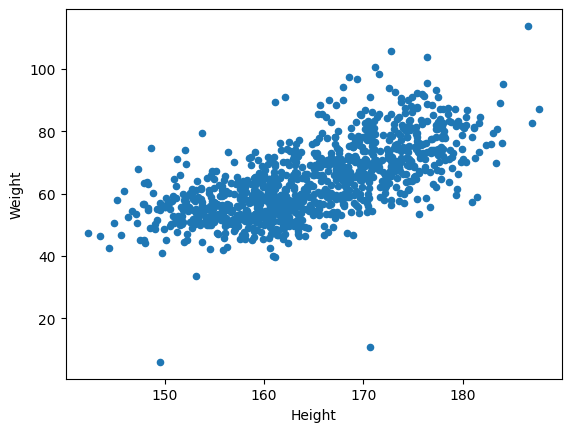

In [ ]:
body_df.plot.scatter(x='Height',y='Weight')
#양의 상관관계를 가짐. 키가 크면 체중이 증가하는 추세를 보임

<Axes: xlabel='Height', ylabel='Body fat percentage'>

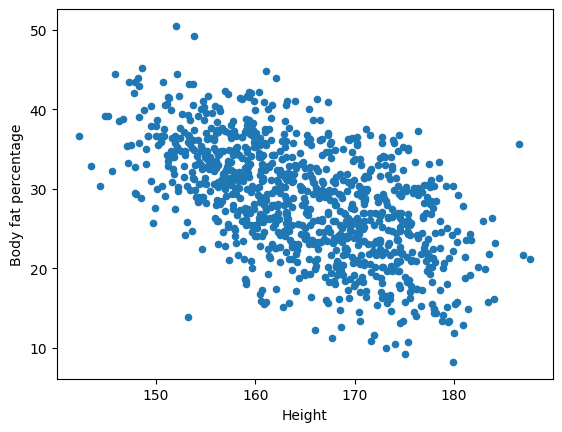

In [ ]:
body_df.plot.scatter(x='Height', y='Body fat percentage')
#음의 상관관계를 가짐. 키가 증가하면 체지방률이 줄어드는 추세를 보임

<Axes: xlabel='Age', ylabel='Weight'>

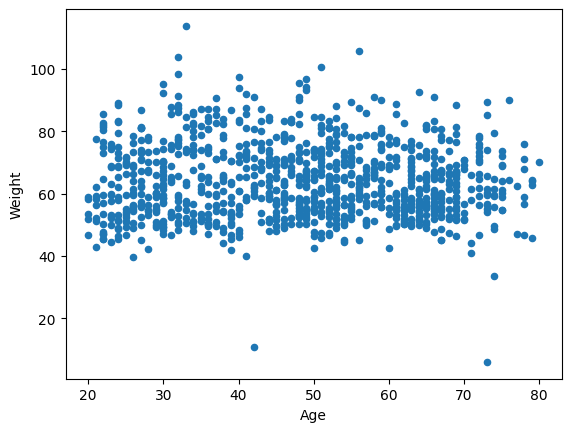

In [ ]:
body_df.plot.scatter(x='Age', y='Weight')
#본 산점도 상에서는 어떤 상관 관계를 지녔는지 추측하기 어려움
#무관한 선형 상관 관계
#선형 상관 관계가 없다고 해서 상관 관계가 없는 것은 아니며
#이는 보통 비선형 상관 관계이다.

의미 있다 없다는 무언가를 통해 상대방을 내 쪽으로 설득시킬 수 있다면 가능한 것. 또한 겉으로 보이는 것과 실제 상관 관계와는 차이가 있음

0의 근사치일 수록 선형 상관 관계가 작다
1의 근사치일 수록 선형 상관 관계가 크다

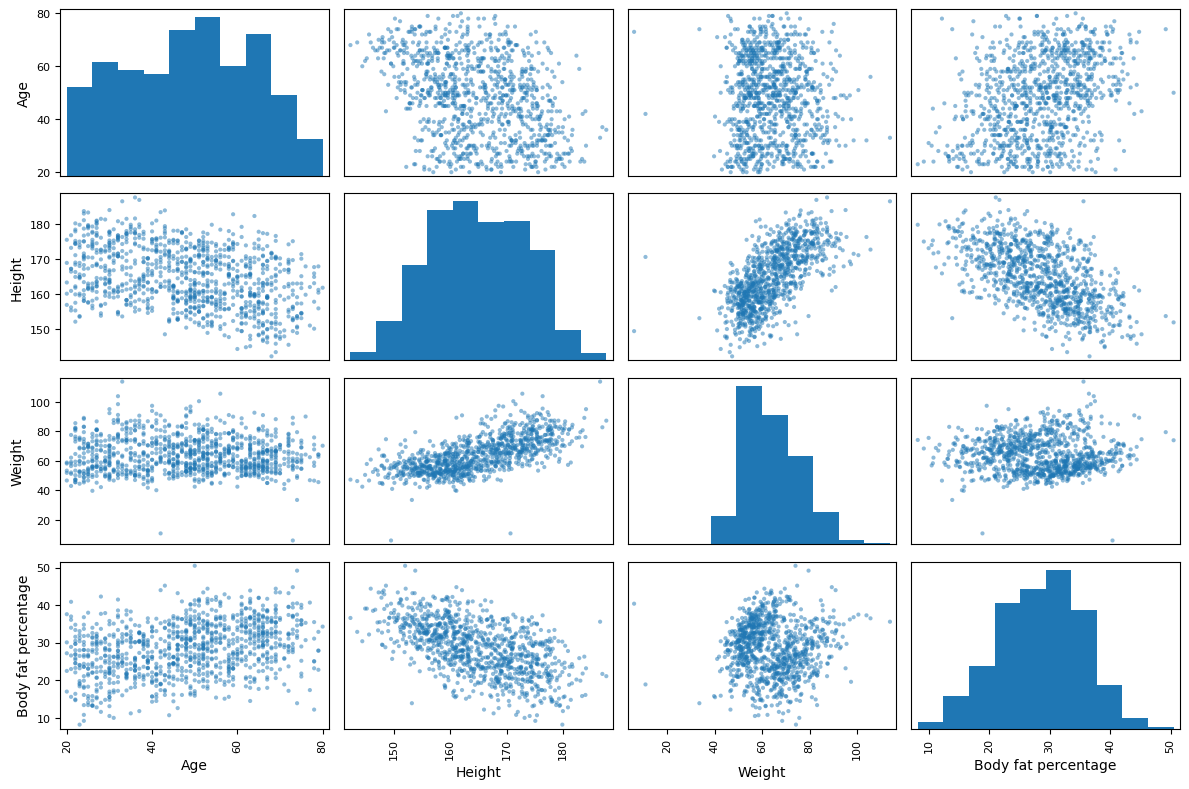

In [14]:
from pandas.plotting import scatter_matrix
axs=scatter_matrix(body_df.iloc[:,1:], figsize=(12,8))

plt.tight_layout()
plt.show()

같은 weight와 height인데 왜 기울기가 다르게 나오는가? 축이 달라서?
그래서 그림이 잘 표현되어야 하는 것이다. 보기에 따라서 달라지니 사용 척도도 천차만별이 될 수 있다.

In [5]:
body_df.cov(ddof=0, numeric_only=True)

,Age,Height,Weight,Body fat percentage
Age,232.177671,-47.943871,-7.074432,36.136552
Height,-47.943871,73.004293,67.435018,-34.197707
Weight,-7.074432,67.435018,143.471750,-0.116165
Body fat percentage,36.136552,-34.197707,-0.116165,49.334098


In [9]:
body_df[['Height','Body fat percentage']].cov(ddof=0)

,Height,Body fat percentage
Height,73.004293,-34.197707
Body fat percentage,-34.197707,49.334098


상관관계와 인과관계는 서로 다르다.
***
X가 아이스크림 판매량이고
Y가 에어컨 판매량이라면

X,Y의 상관 관계는 높을 것이다.

X와 Y의 판매량 중 X의 판매량이 당연히 높긴 하겠으나

X의 판매량이 증가하면 Y의 판매량 역시 증가한다 볼 수 있다.

예를 들어서 날이 더워지면 아이스크림 판매량이 늘고, 에어컨 판매량 역시 늘 것이기 때문이다.
***

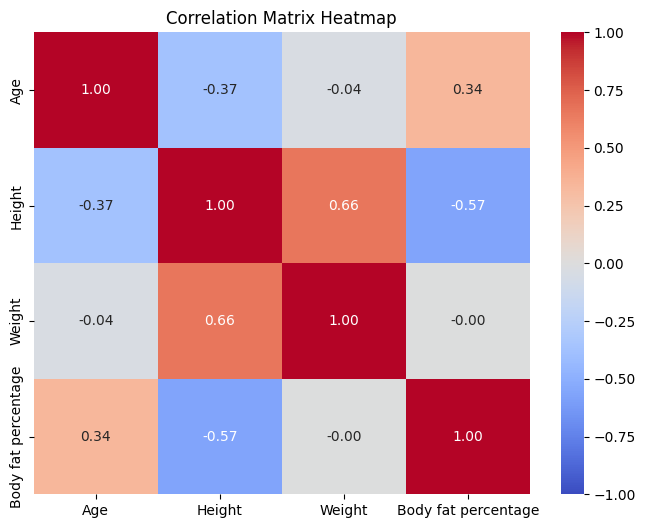

In [13]:
import seaborn as sns

corr_matrix=body_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            vmin=-1,
            vmax=1)

plt.title('Correlation Matrix Heatmap')
plt.show()

In [14]:
penguins=sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
penguins.info()
#bill과 flipper에 결측치 각 2개
#sex에 결측치 11개

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [18]:
na_rows_mask=penguins.isna().any(axis=1)
penguins[na_rows_mask]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [ ]:
penguins=penguins.dropna() #penguins데이터에서 NaN값 없앰
penguins.info() #penguins 데이터 정보 출력

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.8 KB


In [20]:
penguins['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

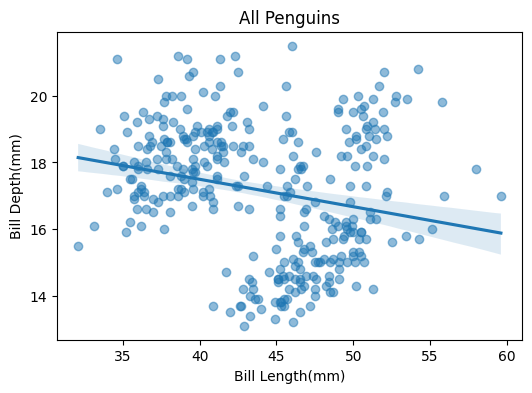

In [21]:
plt.figure(figsize=(6,4))

sns.regplot(data=penguins,
            x="bill_length_mm",
            y="bill_depth_mm",
            scatter_kws={'alpha':0.5})

plt.title("All Penguins")
plt.xlabel("Bill Length(mm)")
plt.ylabel("Bill Depth(mm)")
plt.show()

In [22]:
penguins[['bill_length_mm', 'bill_depth_mm']].corr()

,bill_length_mm,bill_depth_mm
bill_length_mm,1.000000,-0.228626
bill_depth_mm,-0.228626,1.000000


<Figure size 800x600 with 0 Axes>

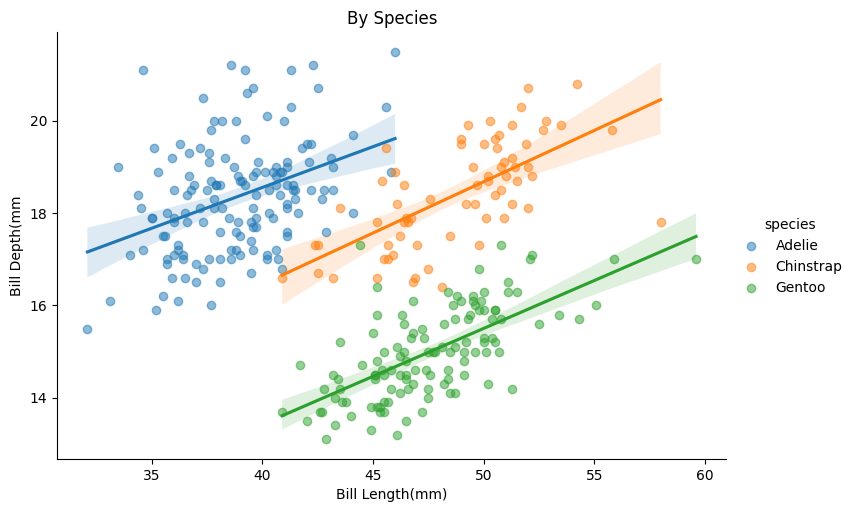

In [23]:
plt.figure(figsize=(8,6))
sns.lmplot(data=penguins,
           x="bill_length_mm",
           y="bill_depth_mm",
           hue="species",
           height=5,
           aspect=1.5,
           scatter_kws={'alpha':0.5})

plt.title("By Species")
plt.xlabel("Bill Length(mm)")
plt.ylabel("Bill Depth(mm")
plt.show()

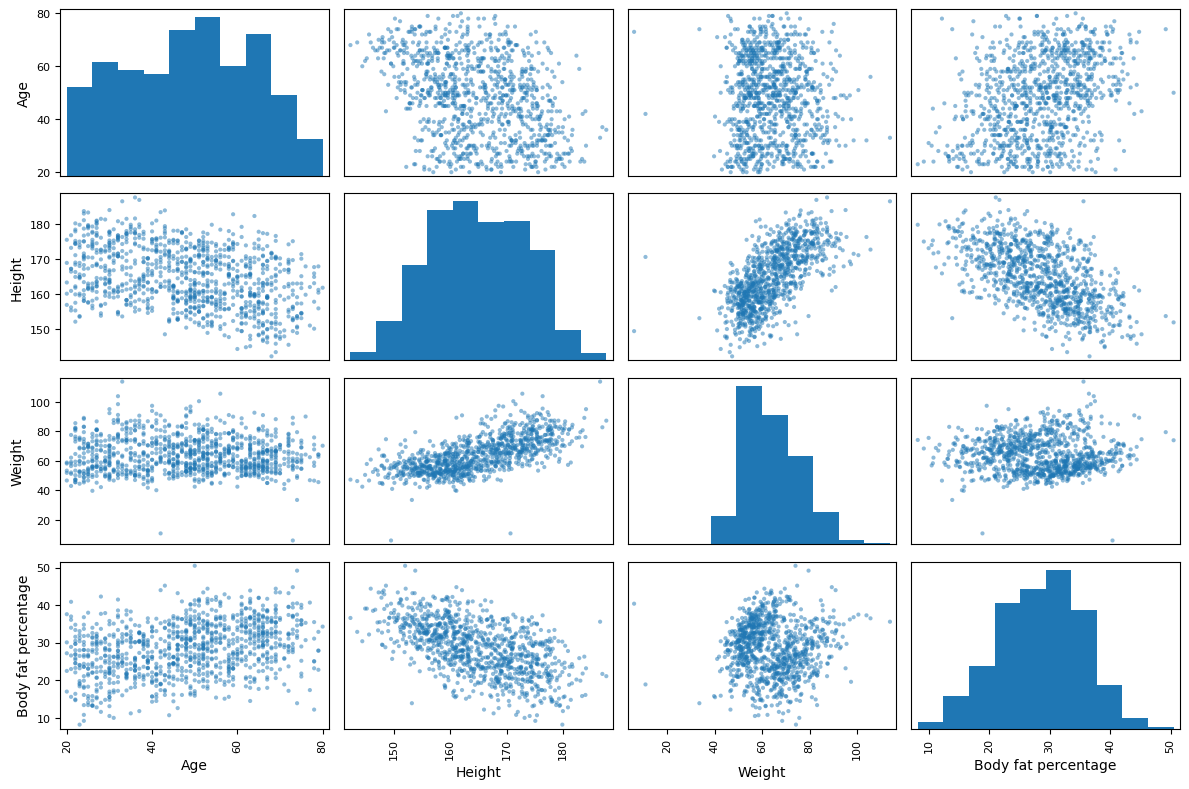

In [6]:
from pandas.plotting import scatter_matrix

# 산점도 행렬 생성
axs = scatter_matrix(body_df.iloc[:, 1:], figsize=(12, 8))

# 플롯 간격 조정
plt.tight_layout()
plt.show()

In [8]:
#표준화를 통해서 키 특성값의 척도를 다르게 하더라도 다른 특성들과의 상관 계수가 달라지지 않는다.
height_col = body_df[['Height']]
height_z = (height_col - height_col.mean()) / height_col.std(ddof=0)

body_df_copy = body_df.copy()
body_df_copy['Height_z'] = height_z
body_df_copy.corr(numeric_only=True).loc[['Height','Height_z']]

,Age,Height,Weight,Body fat percentage,Height_z
Height,-0.368255,1.0,0.658913,-0.569835,1.0
Height_z,-0.368255,1.0,0.658913,-0.569835,1.0


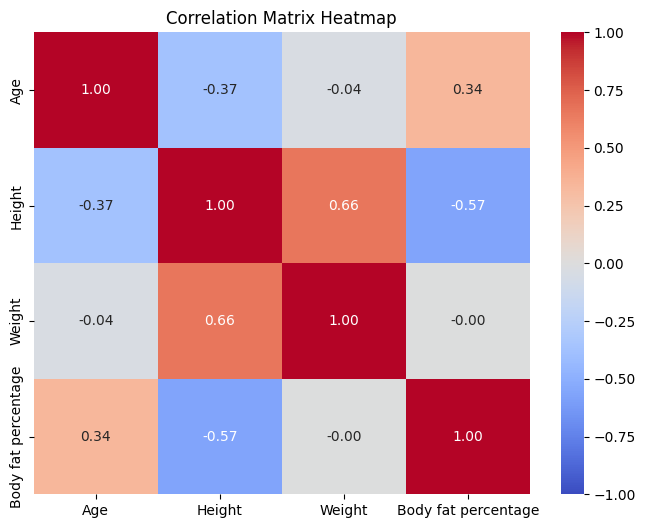

In [16]:
import seaborn as sns

corr_matrix = body_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,        # 각 셀에 실제 데이터(상관계수) 값 표시 여부
            cmap='coolwarm',   # 색상 맵 지정 (파란색에서 빨간색으로 변하는 색상)
            fmt='.2f',         # 셀 안의 숫자 표시 형식 지정 (소수점 둘째 자리까지)
            vmin=-1,           # 색막대의 최솟값 지정 (상관계수의 최솟값인 -1)
            vmax=1)            # 색막대의 최댓값 지정 (상관계수의 최댓값인 1)

plt.title('Correlation Matrix Heatmap')
plt.show()

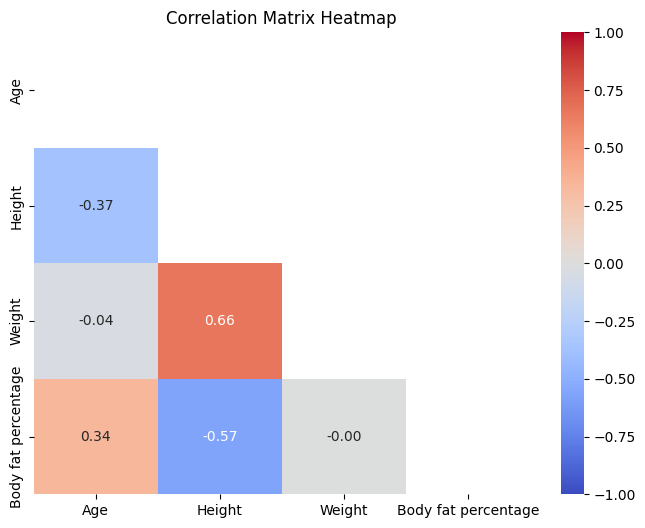

In [14]:
import seaborn as sns

corr_matrix = body_df.corr(numeric_only=True)

# 대각선 포함 위쪽 삼각형 영역 마스킹
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            vmin=-1, 
            vmax=1, 
            mask=mask)

plt.title('Correlation Matrix Heatmap')
plt.show()

In [17]:
anscombe = pd.read_csv(data_url + "anscombe.csv")
anscombe

,x1,x2,x3,x4,y1,y2,y3,y4
0,10,10,10,8,8.04,9.14,7.46,6.58
1,8,8,8,8,6.95,8.14,6.77,5.76
2,13,13,13,8,7.58,8.74,12.74,7.71
3,9,9,9,8,8.81,8.77,7.11,8.84
4,11,11,11,8,8.33,9.26,7.81,8.47
5,14,14,14,8,9.96,8.10,8.84,7.04
6,6,6,6,8,7.24,6.13,6.08,5.25
7,4,4,4,19,4.26,3.10,5.39,12.50
8,12,12,12,8,10.84,9.13,8.15,5.56
9,7,7,7,8,4.82,7.26,6.42,7.91


In [18]:
for i in range(0, 4):
    # 1~4번째 데이터셋 추출
    i_th_dataset = anscombe.iloc[:, [i, i + 4]]

    # 데이터셋의 요약 통계량과 상관계수 출력 
    print(f"{i+1}번째 데이터셋:\n")
    print(i_th_dataset.describe().iloc[1:3])
    print(f"상관계수  {i_th_dataset.corr().iloc[0, 1]:.6f}")
    if i < 3:
        print('\n' + '-'*10 + '\n')


1번째 데이터셋:

            x1        y1
mean  9.000000  7.500909
std   3.316625  2.031568
상관계수  0.816421

----------

2번째 데이터셋:

            x2        y2
mean  9.000000  7.500909
std   3.316625  2.031657
상관계수  0.816237

----------

3번째 데이터셋:

            x3        y3
mean  9.000000  7.500000
std   3.316625  2.030424
상관계수  0.816287

----------

4번째 데이터셋:

            x4        y4
mean  9.000000  7.500909
std   3.316625  2.030579
상관계수  0.816521


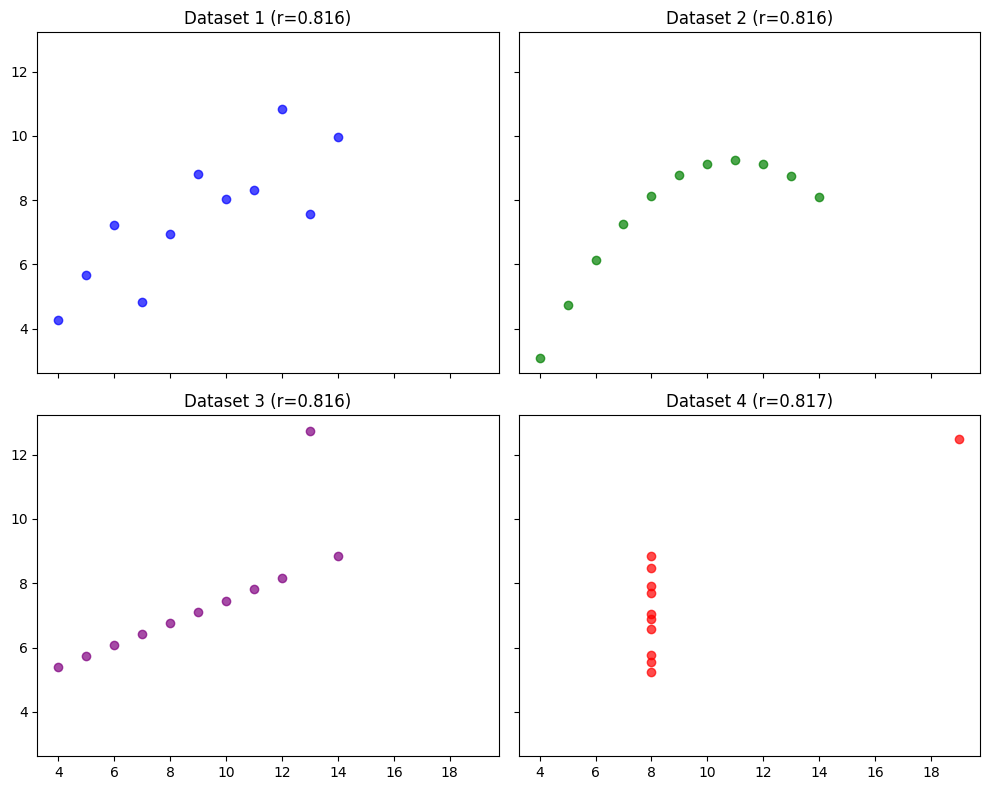

In [ ]:
# 2행 2열 멀티 차트 서브플롯 준비
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

# Dataset 1
ax[0, 0].scatter(anscombe['x1'], anscombe['y1'], color='blue', alpha=0.7)
ax[0, 0].set_title(f"Dataset 1 (r={anscombe['x1'].corr(anscombe['y1']):.3f})")

# Dataset 2
ax[0, 1].scatter(anscombe['x2'], anscombe['y2'], color='green', alpha=0.7)
ax[0, 1].set_title(f"Dataset 2 (r={anscombe['x2'].corr(anscombe['y2']):.3f})")

# Dataset 3
ax[1, 0].scatter(anscombe['x3'], anscombe['y3'], color='purple', alpha=0.7)
ax[1, 0].set_title(f"Dataset 3 (r={anscombe['x3'].corr(anscombe['y3']):.3f})")

# Dataset 4
ax[1, 1].scatter(anscombe['x4'], anscombe['y4'], color='red', alpha=0.7)
ax[1, 1].set_title(f"Dataset 4 (r={anscombe['x4'].corr(anscombe['y4']):.3f})")

plt.tight_layout()
plt.show()

#그래프를 그려보기 전까지 수치만 보고 강한 양의 선형 상관 관계로 오판할 수 있다.
#시각화의 결과는 데이터마다 완전히 다르다

In [21]:
#심슨의 역설은 전체 데이터를 두고 본 상관 관계와 그룹별 상관관계가
#역전되어 나타나는 현상을 말한다.

In [22]:
import seaborn as sns

penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [23]:
na_rows_mask = penguins.isna().any(axis=1)
penguins[na_rows_mask]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [24]:
penguins=penguins.dropna()
penguins.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.8 KB


In [25]:
penguins['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [26]:
penguins['island'].value_counts()

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

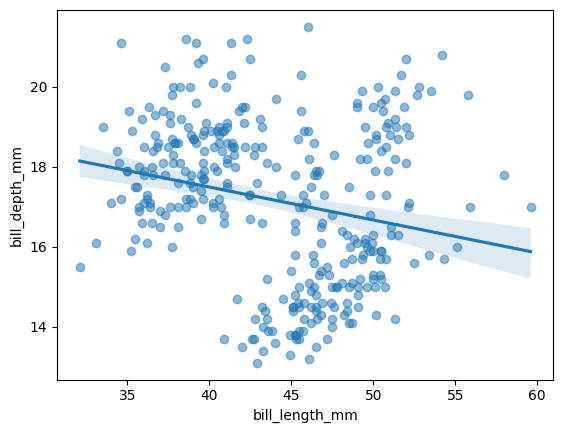

In [28]:
sns.regplot(data=penguins,
            x="bill_length_mm",
            y="bill_depth_mm",
            scatter_kws={"alpha":0.5})

In [29]:
penguins[['bill_length_mm', 'bill_depth_mm']].corr()

,bill_length_mm,bill_depth_mm
bill_length_mm,1.000000,-0.228626
bill_depth_mm,-0.228626,1.000000


In [34]:
penguins.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


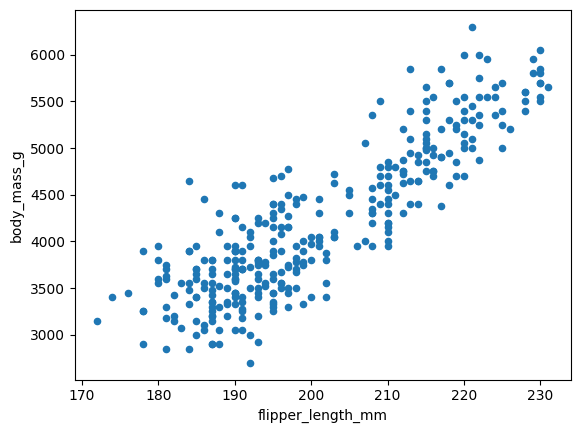

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins").dropna() # 결측치 제거

penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g')
plt.show()

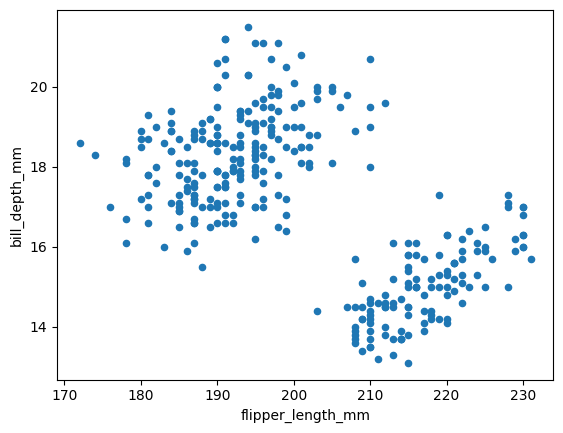

In [41]:
penguins=penguins.dropna()

penguins.plot.scatter(x='flipper_length_mm',y='bill_depth_mm')
plt.show()

In [43]:
penguins[['flipper_length_mm', 'bill_length_mm']].cov(ddof=0)

,flipper_length_mm,bill_length_mm
flipper_length_mm,195.851762,49.907870
bill_length_mm,49.907870,29.816525


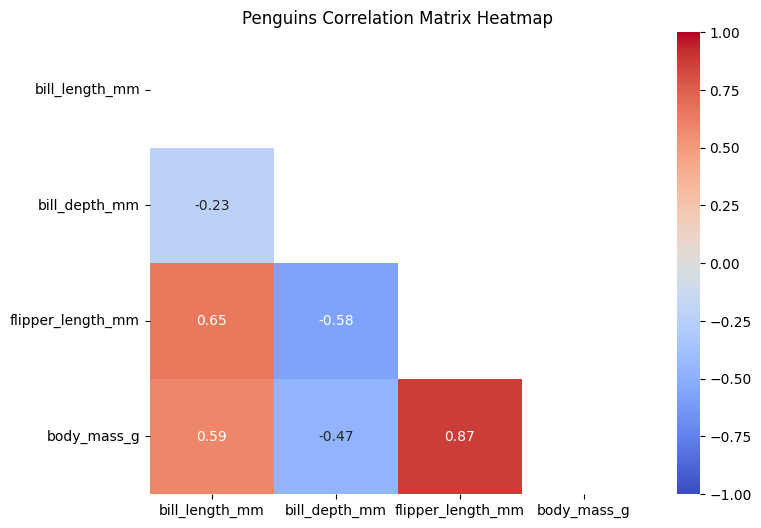

In [50]:
corr_matrix=penguins.corr(numeric_only=True)

mask=np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask)
plt.title('Penguins Correlation Matrix Heatmap')
plt.show()